In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


#### most influential factors: 
- 1. Glucose, 2. BMI

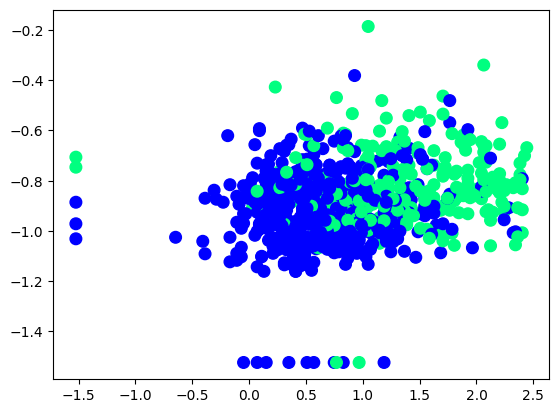

In [33]:
x = df[['Glucose','BMI']].values
y = df['Outcome'].values
x = (x - x.mean()) / x.std()

plt.scatter(x[:,0], x[:,1], c = y, cmap = 'winter', s = 70)

# Step fn

In [41]:
# step function
def step(z):
    if z >= 0:
        return 1
    else:
        return 0

def preceptron_step(x,y):
    lr = 0.01
    x = np.insert(x, 0, 1, axis = 1)
    weights = np.ones(x.shape[1]) # 1,1,1

    for i in range(1000):
        id = np.random.randint(0, x.shape[0])
        y_pred = step(np.dot(x[id] , weights))
        weights += (lr * (y[id] - y_pred) * x[id])

    intercept = weights[0]
    coef = weights[1:]
    return intercept, coef 

Intercept:  0.7199999999999998
Coef:  [0.14983523 1.09280175]


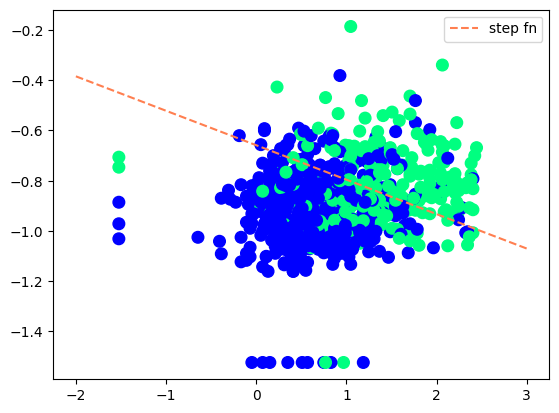

In [42]:
intercept, coef = preceptron_step(x,y)
print('Intercept: ',intercept)
print('Coef: ',coef)

m = -coef[0] / coef[1]
b = -intercept / coef[1]

x_input = np.linspace(-2,3,768)
y_input = m * x_input + b

plt.scatter(x[:,0], x[:,1], c = y, cmap = 'winter', s = 70)
plt.plot(x_input, y_input, color = 'coral', ls = 'dashed', label = 'step fn')
plt.legend()
plt.show()

# Sigmoid fn

In [44]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def preceptron_sig(x,y):
    lr = 0.01
    x = np.insert(x, 0, 1, axis = 1)
    weights = np.ones(x.shape[1]) # 1,1,1

    for i in range(1000):
        id = np.random.randint(0, x.shape[0])
        y_pred = sigmoid(np.dot(x[id] , weights))
        weights += (lr * (y[id] - y_pred) * x[id])

    intercept = weights[0]
    coef = weights[1:]
    return intercept, coef 

intercept:  0.24927432248416048
coef:  [1.05513632 1.75871591]


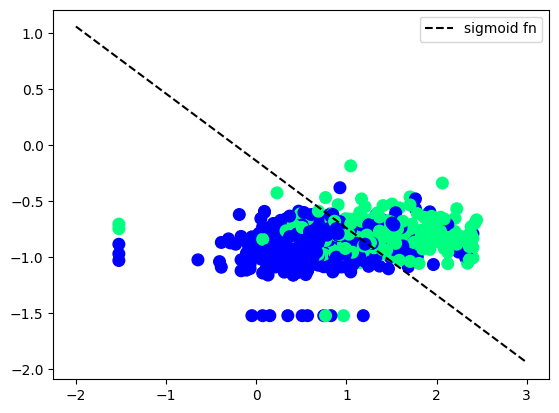

In [45]:
it,cf = preceptron_sig(x,y)
print('intercept: ',it)
print('coef: ',cf)

m2 = -cf[0] / cf[1]
b2 = -it / cf[1]

x_ip = np.linspace(-2,3,768)
y_ip = m2 * x_ip + b2

plt.scatter(x[:,0], x[:,1], c = y, cmap = 'winter', s = 70)
plt.plot(x_ip, y_ip, color = 'k', ls = 'dashed', label = 'sigmoid fn')
plt.legend()
plt.show()

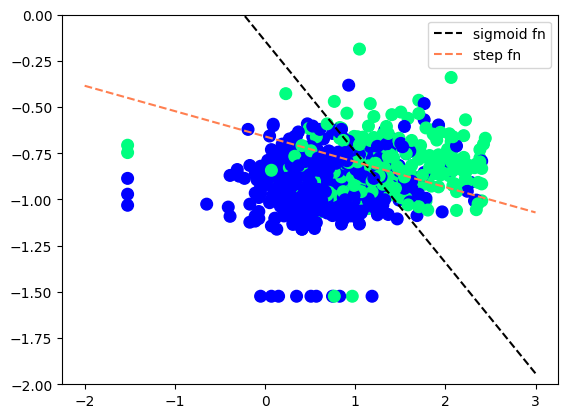

In [47]:
plt.scatter(x[:,0], x[:,1], c = y, cmap = 'winter', s = 70)
plt.plot(x_ip, y_ip, color = 'k', ls = 'dashed', label = 'sigmoid fn')
plt.plot(x_input, y_input, color = 'coral', ls = 'dashed', label = 'step fn')
plt.legend()
plt.ylim(-2,0)
plt.show()

In [52]:
# predict functions

# predict step
def predict_step(x, intercept, coef):
    x = np.insert(x,0,1, axis = 1)
    weights = np.insert(coef, 0, intercept)

    y_pred = []
    for i in range(x.shape[0]):
        y_pred.append(step(np.dot(x[i], weights)))
    
    return np.array(y_pred)

# predict sigmoid
def predict_sig(x, intercept ,coef):
    x = np.insert(x,0,1, axis = 1)
    weights = np.insert(coef, 0, intercept)

    y_pred = sigmoid(np.dot(x,weights))
    return (y_pred >= 0.5).astype(int)

# importing accuracy
from sklearn.metrics import accuracy_score
y_pred_sig = predict_sig(x, it, cf)
y_pred_step = predict_step(x, intercept, coef)

# accuracies
acc_sigmoid = accuracy_score(y, y_pred_sig)
acc_step = accuracy_score(y, y_pred_step)

print('Accuracy sigmoid: ',acc_sigmoid)
print('Accuracy step: ',acc_step)

Accuracy sigmoid:  0.7669270833333334
Accuracy step:  0.7239583333333334


[]

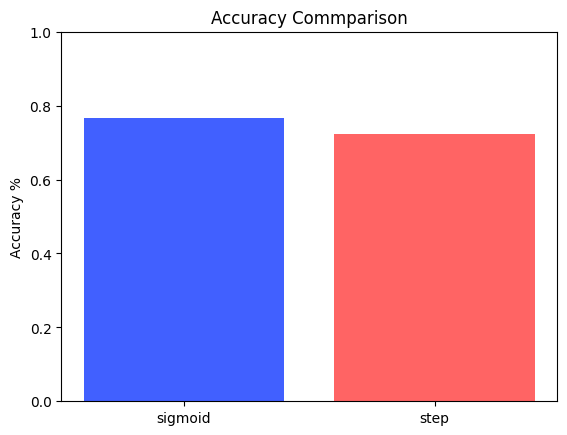

In [64]:
data = {
    'sigmoid':acc_sigmoid,
    'step':acc_step
}
plt.bar(data.keys(), data.values(), color = ["#4160FF","#ff6464"], width=0.8, align='center')
plt.ylabel('Accuracy %')
plt.title('Accuracy Commparison')
plt.ylim(0, 1)
plt.plot()